# sim_dw_complex.ipynb

**목적**: 복소수 DW가 advection 부호를 복원하는지 시뮬레이션으로 검증

**파이프라인**:
- FFT circulant embedding → target regular grid에 직접 field 생성 (고해상도 불필요)
- 복소수 DW likelihood로 파라미터 추정
- **핵심 지표**: advec_lat / advec_lon 부호 복원율 (기대 ~1.0)

**수학적 근거**:
- 실수 DW: `L(advec) = L(-advec)` (cos 대칭) → 부호 복원 불가
- 복소수 DW: `F(ω;-α) = F(ω;α)*` ≠ `F(ω;α)` → `L(-α) ≠ L(α)` → 부호 복원 가능
- 단, log-det 기여는 ±α에서 동일 → **trace term만** 부호 구분

In [1]:
import sys
import time
import numpy as np
import torch
import torch.fft
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
sys.path.append(gems_tco_path)

from GEMS_TCO import debiased_whittle_complex as debiased_whittle

DEVICE    = torch.device("cpu")
DTYPE     = torch.float64
DELTA_LAT = 0.044
DELTA_LON = 0.063

print(f"Module : debiased_whittle_complex")
print(f"Device : {DEVICE}")

Module : debiased_whittle_complex
Device : cpu


## 1. 설정

In [2]:
# ── True parameters ──────────────────────────────────────────────────────────
TRUE = {
    'sigmasq':    13.059,
    'range_lat':  0.154,
    'range_lon':  0.195,
    'range_time': 1.0,
    'advec_lat':  0.0218,
    'advec_lon':  -0.1689,
    'nugget':     0.247,
}

phi2     = 1.0 / TRUE['range_lon']
phi1     = TRUE['sigmasq'] * phi2
phi3     = (TRUE['range_lon'] / TRUE['range_lat'])  ** 2
phi4     = (TRUE['range_lon'] / TRUE['range_time']) ** 2
TRUE_LOG = [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
            TRUE['advec_lat'], TRUE['advec_lon'], np.log(TRUE['nugget'])]
TRUE_PARAMS = torch.tensor(TRUE_LOG, device=DEVICE, dtype=DTYPE)

# ── Simulation settings ───────────────────────────────────────────────────────
NUM_ITERS  = 20      # ← 로컬 테스트: 20회. Amarel에서는 300
T_STEPS    = 8
DWL_STEPS  = 5
INIT_NOISE = 0.7     # log-space noise for phi params
SEED       = 42

LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

LAT_COL, LON_COL, VAL_COL = 0, 1, 2

P_LABELS = ['sigmasq', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget']
P_COLS   = ['sigmasq_est', 'range_lat_est', 'range_lon_est', 'range_t_est',
            'advec_lat_est', 'advec_lon_est', 'nugget_est']
TV_LIST  = [TRUE[k] for k in ['sigmasq','range_lat','range_lon','range_time',
                                'advec_lat','advec_lon','nugget']]

print(f"NUM_ITERS : {NUM_ITERS}")
print(f"True advec_lat = {TRUE['advec_lat']:+.4f},  advec_lon = {TRUE['advec_lon']:+.4f}")

NUM_ITERS : 20
True advec_lat = +0.0218,  advec_lon = -0.1689


## 2. 헬퍼 함수

In [3]:
# ── Covariance kernel (for circulant embedding) ───────────────────────────────
def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist  = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)


# ── FFT field generation on target grid ───────────────────────────────────────
def generate_field_on_grid(n_lat, n_lon, t_steps, params, dlat, dlon):
    """Circulant embedding realization directly on the target regular grid."""
    CPU = torch.device("cpu")
    F32 = torch.float32
    Px, Py, Pt = 2 * n_lat, 2 * n_lon, 2 * t_steps

    lx = torch.arange(Px, device=CPU, dtype=F32) * dlat; lx[Px//2:] -= Px * dlat
    ly = torch.arange(Py, device=CPU, dtype=F32) * dlon; ly[Py//2:] -= Py * dlon
    lt = torch.arange(Pt, device=CPU, dtype=F32);        lt[Pt//2:] -= Pt

    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing='ij')
    C = get_covariance_on_grid(Lx, Ly, Lt, params.cpu().float())
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(Px, Py, Pt, device=CPU, dtype=F32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(dtype=DTYPE, device=DEVICE)


# ── Dataset assembly ──────────────────────────────────────────────────────────
def assemble_tensor_list(field, lats_grid, lons_grid, true_params, t_steps):
    """Build time-slice tensor list. Each tensor: (N_grid, 3) = [lat, lon, val]."""
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    g_lat, g_lon = torch.meshgrid(lats_grid, lons_grid, indexing='ij')
    coords  = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    N_grid  = coords.shape[0]
    tensor_list = []
    for t_idx in range(t_steps):
        gp_vals  = field[:, :, t_idx].flatten()
        sim_vals = gp_vals + torch.randn(N_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows = torch.zeros((N_grid, 3), device=DEVICE, dtype=DTYPE)
        rows[:, 0] = coords[:, 0]
        rows[:, 1] = coords[:, 1]
        rows[:, 2] = sim_vals
        tensor_list.append(rows)
    return tensor_list


# ── Parameter back-mapping ────────────────────────────────────────────────────
def backmap_params(p_list):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in p_list]
    phi2 = np.exp(p[1]); rlon = 1.0 / phi2
    return {
        'sigmasq':    np.exp(p[0]) / phi2,
        'range_lat':  rlon / np.exp(p[2]) ** 0.5,
        'range_lon':  rlon,
        'range_time': rlon / np.exp(p[3]) ** 0.5,
        'advec_lat':  p[4],
        'advec_lon':  p[5],
        'nugget':     np.exp(p[6]),
    }


# ── Random init ───────────────────────────────────────────────────────────────
def make_random_init(rng, init_noise=INIT_NOISE):
    noisy = list(TRUE_LOG)
    for i in [0, 1, 2, 3, 6]:                      # log-params: ±init_noise
        noisy[i] = TRUE_LOG[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:                                # advec: ±0.3 → ~50% wrong sign
        noisy[i] = TRUE_LOG[i] + rng.uniform(-0.3, 0.3)
    return noisy


print("Helper functions defined.")

Helper functions defined.


In [4]:
# ── Build target grid (once) ──────────────────────────────────────────────────
lats_grid = torch.arange(min(LAT_RANGE), max(LAT_RANGE) + 0.0001, DELTA_LAT,
                          device=DEVICE, dtype=DTYPE)
lons_grid = torch.arange(LON_RANGE[0], LON_RANGE[1] + 0.0001, DELTA_LON,
                          device=DEVICE, dtype=DTYPE)
lats_grid = torch.round(lats_grid * 10000) / 10000
lons_grid = torch.round(lons_grid * 10000) / 10000
n_lat, n_lon = len(lats_grid), len(lons_grid)

print(f"Target grid : {n_lat} lat × {n_lon} lon = {n_lat*n_lon} cells")
print(f"lats_grid   : {lats_grid[0].item():.3f} → {lats_grid[-1].item():.3f}  (ASCENDING ✓)")
print(f"lons_grid   : {lons_grid[0].item():.3f} → {lons_grid[-1].item():.3f}  (ASCENDING ✓)")
print(f"T_STEPS     : {T_STEPS}")

Target grid : 114 lat × 159 lon = 18126 cells
lats_grid   : -3.000 → 1.972  (ASCENDING ✓)
lons_grid   : 121.000 → 130.954  (ASCENDING ✓)
T_STEPS     : 8


## 3. 시뮬레이션 루프

In [5]:
dwl = debiased_whittle.debiased_whittle_likelihood()
rng = np.random.default_rng(SEED)

records = []
skipped = 0

for it in range(NUM_ITERS):
    print(f"\n{'='*55}")
    print(f"  Iter {it+1}/{NUM_ITERS}  (skipped: {skipped})")
    print(f"{'='*55}")

    initial_vals = make_random_init(rng)
    init_orig    = backmap_params(initial_vals)
    print(f"  init advec_lat={init_orig['advec_lat']:+.4f}  "
          f"advec_lon={init_orig['advec_lon']:+.4f}  "
          f"sigmasq={init_orig['sigmasq']:.2f}")

    init_sign_lat = '+' if init_orig['advec_lat'] >= 0 else '-'
    init_sign_lon = '+' if init_orig['advec_lon'] >= 0 else '-'
    true_sign_lat = '+' if TRUE['advec_lat'] >= 0 else '-'
    true_sign_lon = '+' if TRUE['advec_lon'] >= 0 else '-'
    print(f"  init sign: lat={init_sign_lat} (true={true_sign_lat})  "
          f"lon={init_sign_lon} (true={true_sign_lon})")

    try:
        # ── Generate field ────────────────────────────────────────────────
        field = generate_field_on_grid(n_lat, n_lon, T_STEPS, TRUE_PARAMS,
                                       DELTA_LAT, DELTA_LON)

        # ── Build time-slice tensors ──────────────────────────────────────
        tensor_list = assemble_tensor_list(field, lats_grid, lons_grid,
                                           TRUE_PARAMS, T_STEPS)
        del field

        # ── Demean each slice (DC removal) ────────────────────────────────
        for i in range(len(tensor_list)):
            vals = tensor_list[i][:, VAL_COL]
            tensor_list[i] = tensor_list[i].clone()
            tensor_list[i][:, VAL_COL] = vals - vals.mean()

        # ── DFT & periodogram ─────────────────────────────────────────────
        J_vec, n1, n2, p_time, taper, obs_masks = dwl.generate_Jvector_tapered_mv(
            tensor_list, dwl.cgn_hamming, LAT_COL, LON_COL, VAL_COL, DEVICE)
        I_samp = dwl.calculate_sample_periodogram_vectorized(J_vec)
        t_auto = dwl.calculate_taper_autocorrelation_multivariate(
            taper, obs_masks, n1, n2, DEVICE)
        del obs_masks

        # ── Optimize ──────────────────────────────────────────────────────
        p_dw = [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True)
                for v in initial_vals]
        opt  = torch.optim.LBFGS(
            p_dw, lr=1.0, max_iter=20, max_eval=100,
            history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-5)

        t0 = time.time()
        _, _, _, loss, _ = dwl.run_lbfgs_tapered(
            params_list=p_dw, optimizer=opt, I_sample=I_samp,
            n1=n1, n2=n2, p_time=p_time, taper_autocorr_grid=t_auto,
            max_steps=DWL_STEPS, device=DEVICE)
        elapsed = time.time() - t0

        est = backmap_params([p.item() for p in p_dw])
        lat_sign_ok = int(np.sign(est['advec_lat']) == np.sign(TRUE['advec_lat']))
        lon_sign_ok = int(np.sign(est['advec_lon']) == np.sign(TRUE['advec_lon']))

        true_arr = np.array(TV_LIST)
        est_arr  = np.array([est[k] for k in
                             ['sigmasq','range_lat','range_lon','range_time',
                              'advec_lat','advec_lon','nugget']])
        rmsre = float(np.sqrt(np.mean(((est_arr - true_arr) / np.abs(true_arr))**2)))

        print(f"  RMSRE={rmsre:.4f}  ({elapsed:.1f}s)  "
              f"advec_lat={est['advec_lat']:+.4f}({'✓' if lat_sign_ok else '✗'})  "
              f"advec_lon={est['advec_lon']:+.4f}({'✓' if lon_sign_ok else '✗'})")

    except Exception as e:
        skipped += 1
        import traceback; traceback.print_exc()
        continue

    records.append({
        'iter':              it + 1,
        'rmsre':             round(rmsre, 6),
        'loss':              round(float(loss), 6),
        'time_s':            round(elapsed, 2),
        'sigmasq_est':       round(est['sigmasq'],    6),
        'range_lat_est':     round(est['range_lat'],  6),
        'range_lon_est':     round(est['range_lon'],  6),
        'range_t_est':       round(est['range_time'], 6),
        'advec_lat_est':     round(est['advec_lat'],  6),
        'advec_lon_est':     round(est['advec_lon'],  6),
        'nugget_est':        round(est['nugget'],     6),
        'advec_lat_sign_ok': lat_sign_ok,
        'advec_lon_sign_ok': lon_sign_ok,
        'init_advec_lat':    round(init_orig['advec_lat'], 4),
        'init_advec_lon':    round(init_orig['advec_lon'], 4),
        'n1': n1, 'n2': n2,
    })

df = pd.DataFrame(records)
print(f"\n✓ Done: {len(records)} iters completed, {skipped} skipped")


  Iter 1/20  (skipped: 0)
  init advec_lat=+0.3072  advec_lon=-0.0122  sigmasq=20.88
  init sign: lat=+ (true=+)  lon=- (true=-)
--- Step 1/5 ---
 Loss: -8.666896 | Max Grad: 2.118578e-02
  Params (Raw Log): log_phi1: 4.2435, log_phi2: 1.7105, log_phi3: 0.4683, log_phi4: -3.3760, advec_lat: 0.0278, advec_lon: -0.1645, log_nugget: -1.8271
--- Step 2/5 ---
 Loss: -9.591522 | Max Grad: 3.312741e-06
  Params (Raw Log): log_phi1: 4.1762, log_phi2: 1.6228, log_phi3: 0.4714, log_phi4: -3.3325, advec_lat: 0.0265, advec_lon: -0.1639, log_nugget: -1.1011
--- Step 3/5 ---
 Loss: -9.593662 | Max Grad: 3.312741e-06
  Params (Raw Log): log_phi1: 4.1762, log_phi2: 1.6228, log_phi3: 0.4714, log_phi4: -3.3325, advec_lat: 0.0265, advec_lon: -0.1639, log_nugget: -1.1011
--- Step 4/5 ---
 Loss: -9.593662 | Max Grad: 3.312741e-06
  Params (Raw Log): log_phi1: 4.1762, log_phi2: 1.6228, log_phi3: 0.4714, log_phi4: -3.3325, advec_lat: 0.0265, advec_lon: -0.1639, log_nugget: -1.1011

--- Converged (max|grad| 

## 4. 핵심 지표: 부호 복원율

In [6]:
if len(df) == 0:
    print("No records."); raise SystemExit

lat_rate = df['advec_lat_sign_ok'].mean()
lon_rate = df['advec_lon_sign_ok'].mean()

print(f"{'='*50}")
print(f"  Sign Recovery Rate  (n={len(df)})")
print(f"{'='*50}")
print(f"  advec_lat  true={TRUE['advec_lat']:+.4f}  correct={lat_rate:.3f}")
print(f"  advec_lon  true={TRUE['advec_lon']:+.4f}  correct={lon_rate:.3f}")
print()
print(f"  Reference: real DW → ~0.50 (random), complex DW → ~1.00")

# 잘못된 부호 케이스 출력
wrong = df[(df['advec_lat_sign_ok']==0) | (df['advec_lon_sign_ok']==0)]
if len(wrong) > 0:
    print(f"\n  Wrong-sign cases ({len(wrong)}/{len(df)}):")
    print(wrong[['iter','advec_lat_est','advec_lon_est',
                 'advec_lat_sign_ok','advec_lon_sign_ok',
                 'init_advec_lat','init_advec_lon','rmsre']].to_string(index=False))
else:
    print(f"\n  ✓ No wrong-sign cases — 100% sign recovery")

  Sign Recovery Rate  (n=20)
  advec_lat  true=+0.0218  correct=1.000
  advec_lon  true=-0.1689  correct=1.000

  Reference: real DW → ~0.50 (random), complex DW → ~1.00

  ✓ No wrong-sign cases — 100% sign recovery


## 5. 파라미터 추정 요약

In [7]:
print(f"{'='*70}")
print(f"  {'Parameter':<14} {'True':>10} {'Mean':>10} {'Bias':>10} "
      f"{'Std':>10} {'RMSRE':>10}")
print(f"  {'-'*66}")
for lbl, col, tv in zip(P_LABELS, P_COLS, TV_LIST):
    v     = df[col].values
    bias  = float(np.mean(v) - tv)
    std   = float(np.std(v))
    rmsre = float(np.sqrt(np.mean(((v - tv) / abs(tv))**2)))
    print(f"  {lbl:<14} {tv:>10.4f} {np.mean(v):>10.4f} "
          f"{bias:>10.4f} {std:>10.4f} {rmsre:>10.4f}")
print(f"  {'-'*66}")
overall_rmsre = np.mean([float(np.sqrt(np.mean(((df[c].values-tv)/abs(tv))**2)))
                          for c, tv in zip(P_COLS, TV_LIST)])
print(f"  {'Overall RMSRE':<14} {'':>10} {'':>10} {'':>10} {'':>10} {overall_rmsre:>10.4f}")

  Parameter            True       Mean       Bias        Std      RMSRE
  ------------------------------------------------------------------
  sigmasq           13.0590    12.9390    -0.1200     0.4044     0.0323
  range_lat          0.1540     0.1524    -0.0016     0.0070     0.0463
  range_lon          0.1950     0.1924    -0.0026     0.0080     0.0433
  range_time         1.0000     0.9863    -0.0137     0.0486     0.0505
  advec_lat          0.0218     0.0230     0.0012     0.0063     0.2954
  advec_lon         -0.1689    -0.1676     0.0013     0.0070     0.0419
  nugget             0.2470     0.2359    -0.0111     0.0544     0.2247
  ------------------------------------------------------------------
  Overall RMSRE                                                  0.1049


## 6. 시각화

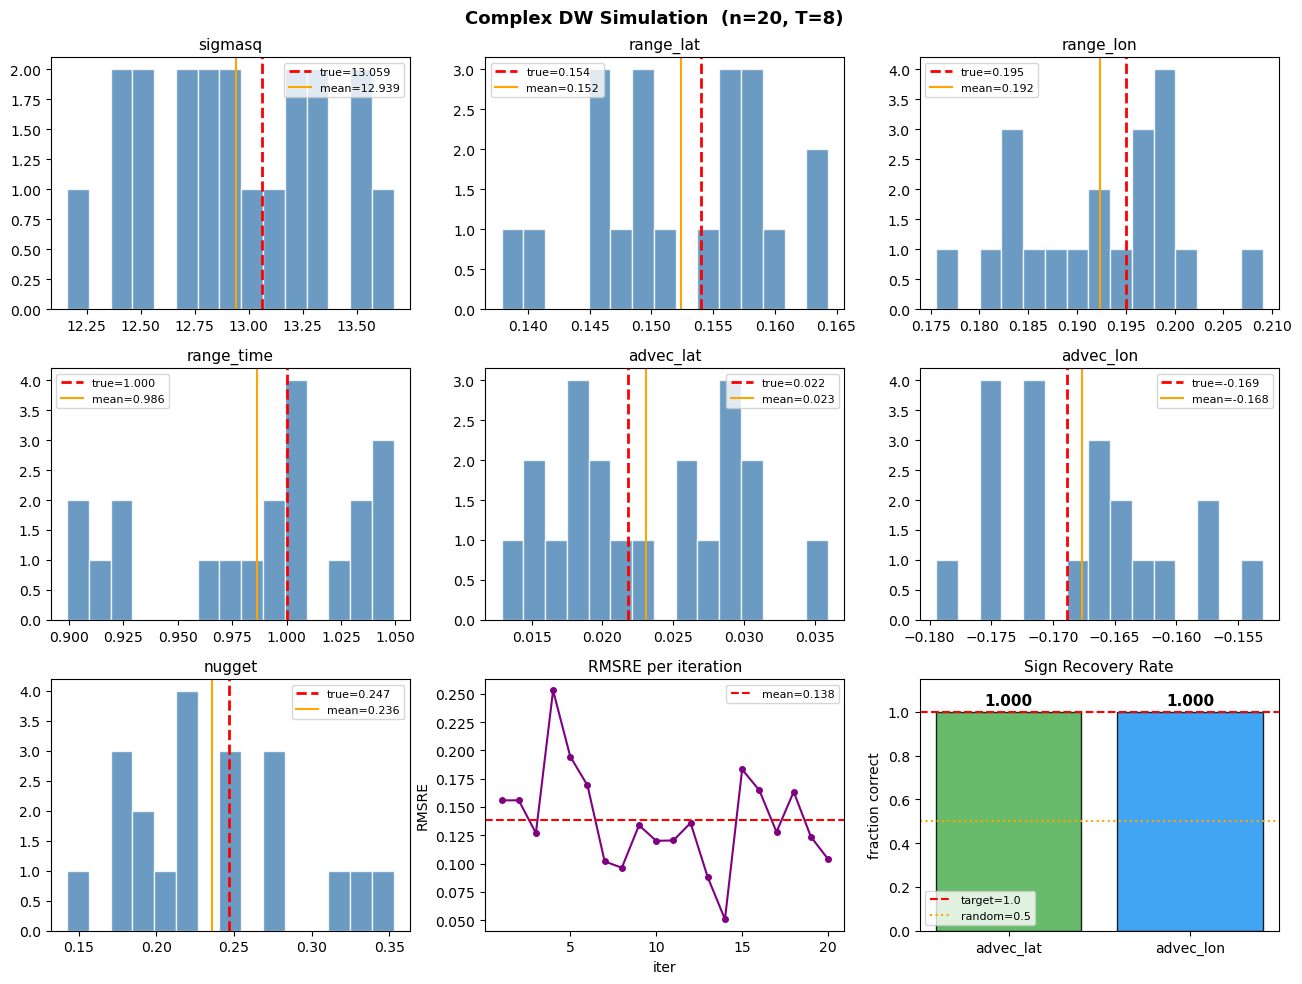

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for ax, lbl, col, tv in zip(axes, P_LABELS, P_COLS, TV_LIST):
    v = df[col].values
    ax.hist(v, bins=min(15, len(v)), color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(tv, color='red',    lw=2, ls='--', label=f'true={tv:.3f}')
    ax.axvline(np.mean(v), color='orange', lw=1.5, ls='-', label=f'mean={np.mean(v):.3f}')
    ax.set_title(lbl, fontsize=11)
    ax.legend(fontsize=8)

# 마지막 패널: RMSRE per iter
ax = axes[7]
ax.plot(df['iter'], df['rmsre'], 'o-', ms=4, color='purple')
ax.set_title('RMSRE per iteration', fontsize=11)
ax.set_xlabel('iter'); ax.set_ylabel('RMSRE')
ax.axhline(df['rmsre'].mean(), color='red', ls='--',
           label=f"mean={df['rmsre'].mean():.3f}")
ax.legend(fontsize=8)

# sign recovery 요약 bar
ax = axes[8]
ax.bar(['advec_lat', 'advec_lon'], [lat_rate, lon_rate],
       color=['#4CAF50','#2196F3'], edgecolor='black', alpha=0.85)
ax.axhline(1.0, color='red', ls='--', lw=1.5, label='target=1.0')
ax.axhline(0.5, color='orange', ls=':', lw=1.5, label='random=0.5')
ax.set_ylim(0, 1.15)
ax.set_title('Sign Recovery Rate', fontsize=11)
ax.set_ylabel('fraction correct')
ax.legend(fontsize=8)
for i, (lbl, v) in enumerate(zip(['advec_lat','advec_lon'],[lat_rate,lon_rate])):
    ax.text(i, v + 0.03, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Complex DW Simulation  (n={len(df)}, T={T_STEPS})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. 부호 오류 케이스 분석

init sign이 틀렸을 때 optimizer가 올바른 sign으로 수렴하는가?

In [13]:
# init sign 분류: correct / wrong
df['init_lat_sign_ok'] = (np.sign(df['init_advec_lat']) == np.sign(TRUE['advec_lat'])).astype(int)
df['init_lon_sign_ok'] = (np.sign(df['init_advec_lon']) == np.sign(TRUE['advec_lon'])).astype(int)

print(f"{'─'*55}")
print(f"  advec_lon sign recovery stratified by init sign")
print(f"{'─'*55}")
for init_ok, label in [(1, 'init correct sign'), (0, 'init WRONG sign')]:
    sub = df[df['init_lon_sign_ok'] == init_ok]
    if len(sub) == 0:
        print(f"  {label}: no cases")
        continue
    rec_rate = sub['advec_lon_sign_ok'].mean()
    print(f"  {label:25s}  n={len(sub):3d}  recovery={rec_rate:.3f}")

print()
print(f"  advec_lat sign recovery stratified by init sign")
print(f"{'─'*55}")
for init_ok, label in [(1, 'init correct sign'), (0, 'init WRONG sign')]:
    sub = df[df['init_lat_sign_ok'] == init_ok]
    if len(sub) == 0:
        print(f"  {label}: no cases")
        continue
    rec_rate = sub['advec_lat_sign_ok'].mean()
    print(f"  {label:25s}  n={len(sub):3d}  recovery={rec_rate:.3f}")

print()
print("  해석: 'init WRONG sign'에서 복원율이 높으면 complex DW가 정말로")
print("  gradient를 통해 올바른 sign으로 optimizer를 유도함을 의미")

───────────────────────────────────────────────────────
  advec_lon sign recovery stratified by init sign
───────────────────────────────────────────────────────
  init correct sign          n= 18  recovery=1.000
  init WRONG sign            n=  2  recovery=1.000

  advec_lat sign recovery stratified by init sign
───────────────────────────────────────────────────────
  init correct sign          n= 12  recovery=1.000
  init WRONG sign            n=  8  recovery=1.000

  해석: 'init WRONG sign'에서 복원율이 높으면 complex DW가 정말로
  gradient를 통해 올바른 sign으로 optimizer를 유도함을 의미


## 8. 5-number summary

In [10]:
print(f"{'='*70}")
print(f"  5-NUMBER SUMMARY  (Min | Q1 | Median | Q3 | Max)")
print(f"{'='*70}")
for lbl, col, tv in zip(P_LABELS, P_COLS, TV_LIST):
    v = df[col].dropna().values
    q1, q2, q3 = np.percentile(v, [25, 50, 75])
    print(f"  {lbl:<14} (true={tv:.4f})"
          f"  {v.min():.4f} | {q1:.4f} | {q2:.4f} | {q3:.4f} | {v.max():.4f}")

  5-NUMBER SUMMARY  (Min | Q1 | Median | Q3 | Max)
  sigmasq        (true=13.0590)  12.1593 | 12.6807 | 12.9319 | 13.2226 | 13.6701
  range_lat      (true=0.1540)  0.1379 | 0.1475 | 0.1527 | 0.1578 | 0.1643
  range_lon      (true=0.1950)  0.1755 | 0.1847 | 0.1939 | 0.1981 | 0.2090
  range_time     (true=1.0000)  0.8992 | 0.9560 | 0.9997 | 1.0283 | 1.0491
  advec_lat      (true=0.0218)  0.0129 | 0.0177 | 0.0221 | 0.0283 | 0.0359
  advec_lon      (true=-0.1689)  -0.1795 | -0.1724 | -0.1672 | -0.1635 | -0.1530
  nugget         (true=0.2470)  0.1425 | 0.1909 | 0.2233 | 0.2711 | 0.3528
